=== 2024 Yield Distribution ===

Total records: 119
Crops: ['Soybean' 'Corn']

=== Statistics by Crop ===
         count        mean        std         min         25%         50%  \
Crop                                                                        
Corn      78.0  214.508100  36.752238  123.658472  187.482087  215.724498   
Soybean   41.0   59.926943  15.365773   12.957271   54.140212   63.394389   

                75%         max  
Crop                             
Corn     248.075496  273.422972  
Soybean   68.699146   83.918829  



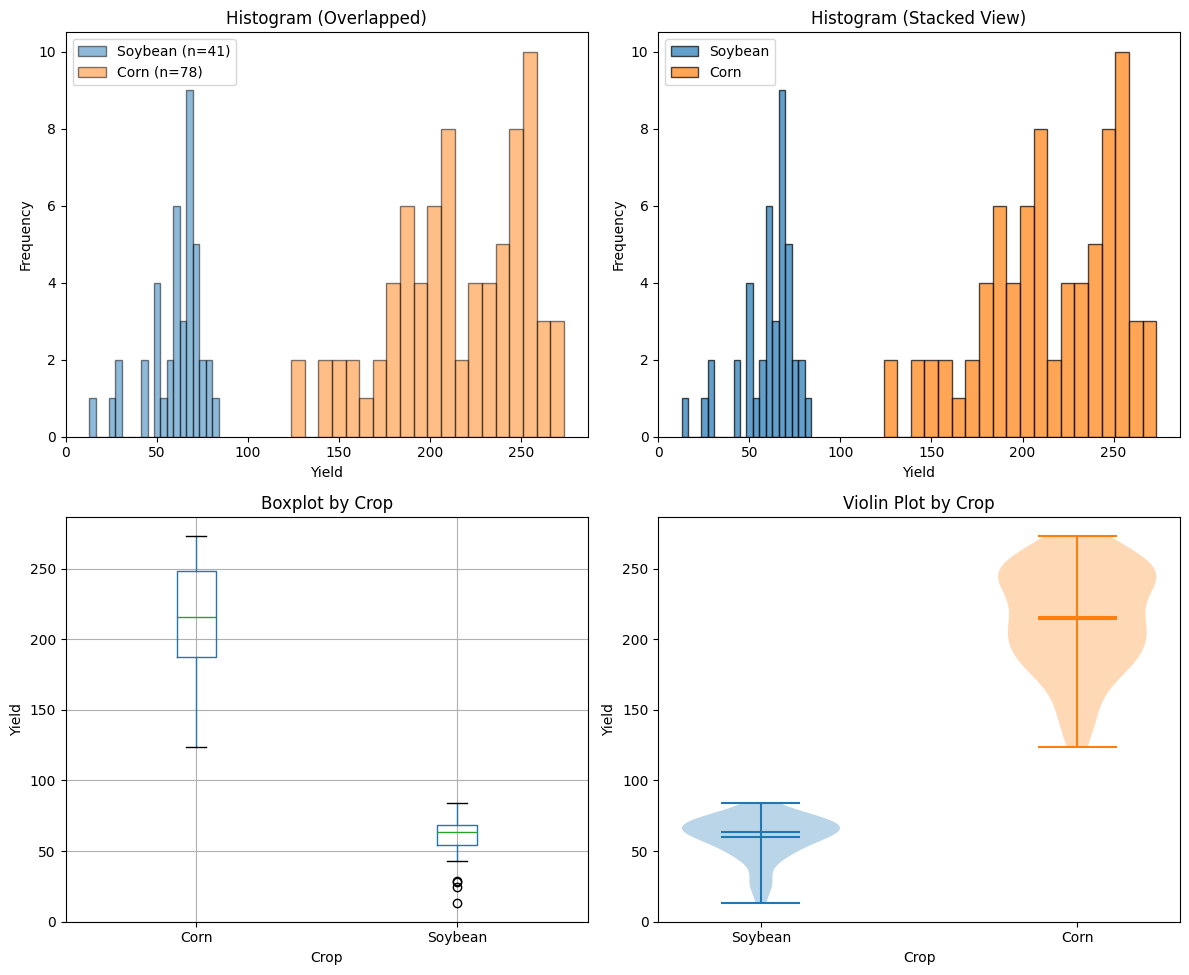

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Dataset load
df = pd.read_csv('/work/mech-ai-scratch/bgekim/project/ISA_Yield_Anirudha/ISA_Yield/yld_proc/raw_yield/Crop_Classification_2022.csv')

print("=== 2024 Yield Distribution ===\n")
print(f"Total records: {len(df)}")
print(f"Crops: {df['Crop'].unique()}")
print()

# Statistic per crop
print("=== Statistics by Crop ===")
print(df.groupby('Crop')['Yield'].describe())
print()

# Visualizations
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle('2022 Yield Distribution by Crop', fontsize=14, fontweight='bold')

# 1. Histogram 
ax1 = axes[0, 0]
for crop in df['Crop'].unique():
    data = df[df['Crop'] == crop]['Yield']
    ax1.hist(data, bins=20, alpha=0.5, label=f'{crop} (n={len(data)})', edgecolor='black')
ax1.set_xlabel('Yield')
ax1.set_ylabel('Frequency')
ax1.set_title('Histogram (Overlapped)')
ax1.legend()

# 2. Histogram 
ax2 = axes[0, 1]
crops = df['Crop'].unique()
for i, crop in enumerate(crops):
    data = df[df['Crop'] == crop]['Yield']
    ax2.hist(data, bins=20, alpha=0.7, label=crop, edgecolor='black')
ax2.set_xlabel('Yield')
ax2.set_ylabel('Frequency')
ax2.set_title('Histogram (Stacked View)')
ax2.legend()

# 3. Boxplot
ax3 = axes[1, 0]
df.boxplot(column='Yield', by='Crop', ax=ax3)
ax3.set_title('Boxplot by Crop')
ax3.set_xlabel('Crop')
ax3.set_ylabel('Yield')
plt.suptitle('')  # Remove automatic title

# 4. Violin plot style using fill_betweenx
ax4 = axes[1, 1]
crops = df['Crop'].unique()
positions = range(len(crops))
for i, crop in enumerate(crops):
    data = df[df['Crop'] == crop]['Yield']
    parts = ax4.violinplot([data], positions=[i], showmeans=True, showmedians=True)
ax4.set_xticks(positions)
ax4.set_xticklabels(crops)
ax4.set_xlabel('Crop')
ax4.set_ylabel('Yield')
ax4.set_title('Violin Plot by Crop')

plt.tight_layout()
plt.show()


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
import glob
import os
from scipy.stats import gaussian_kde

# ============================================================================
# JOURNAL-STANDARD SETTINGS
# ============================================================================
FONT_SIZE = 11
TITLE_SIZE = FONT_SIZE
LABEL_SIZE = FONT_SIZE
TICK_SIZE  = FONT_SIZE
LEGEND_SIZE = FONT_SIZE
ANNOT_SIZE  = FONT_SIZE
INSET_SIZE  = FONT_SIZE

mpl.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['STIXGeneral', 'STIX', 'DejaVu Serif'],
    'mathtext.fontset': 'stix',
    'font.size': FONT_SIZE,
    'axes.labelsize': LABEL_SIZE,
    'axes.titlesize': TITLE_SIZE,
    'xtick.labelsize': TICK_SIZE,
    'ytick.labelsize': TICK_SIZE,
    'legend.fontsize': LEGEND_SIZE,
    'figure.titlesize': FONT_SIZE,
    'axes.linewidth': 0.6,
    'grid.linewidth': 0.4,
    'lines.linewidth': 0.8,
    'patch.linewidth': 0.5,
    'xtick.major.width': 0.6,
    'ytick.major.width': 0.6,
    'xtick.major.size': 3,
    'ytick.major.size': 3,
    'savefig.dpi': 600,
    'savefig.bbox': 'tight',
    'savefig.pad_inches': 0.02,
    'figure.dpi': 150,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'pdf.fonttype': 42,
    'ps.fonttype': 42,
})

DOUBLE_COL = 7.2   # ~183 mm

# Wong (2011) colorblind-safe palette
CB_ORANGE = '#E69F00'
CB_GREEN  = '#009E73'

CORN_COLOR    = CB_ORANGE
SOYBEAN_COLOR = CB_GREEN

OUTPUT_DIR = 'chloe_figures'
os.makedirs(OUTPUT_DIR, exist_ok=True)

def save_fig(fig, name):
    fig.savefig(os.path.join(OUTPUT_DIR, f'{name}.pdf'), bbox_inches='tight', facecolor='white')
    fig.savefig(os.path.join(OUTPUT_DIR, f'{name}.png'), bbox_inches='tight', facecolor='white')
    plt.close(fig)
    print(f'  Saved: {name}.pdf / .png')


# ============================================================================
# DATA LOAD — 2017~2024 
# ============================================================================
DATA_DIR = '/work/mech-ai-scratch/bgekim/project/ISA_Yield_Anirudha/ISA_Yield/yld_proc/raw_yield'
csv_files = sorted(glob.glob(os.path.join(DATA_DIR, 'Crop_Classification_20*.csv')))

df = pd.concat([pd.read_csv(f) for f in csv_files], ignore_index=True)
print(f"Total records : {len(df)}")
print(f"Crops         : {df['Crop'].unique()}")
print(df.groupby('Crop')['Yield'].describe())

# Corn / Soybean filtering + remove outliers 300 bu/acre
corn_data = df[df['Crop'].str.contains('Corn',    case=False, na=False)]['Yield'].dropna()
soy_data  = df[df['Crop'].str.contains('Soybean', case=False, na=False)]['Yield'].dropna()

corn_data = corn_data[(corn_data > 10) & (corn_data < 300)]
soy_data  = soy_data[ (soy_data  > 5)  & (soy_data  < 300)]

box_data    = [corn_data.values, soy_data.values]
crop_labels = ['Corn', 'Soybean']
crop_colors = [CORN_COLOR, SOYBEAN_COLOR]

print(f"\nCorn    n={len(corn_data):,}  mean={corn_data.mean():.1f}  std={corn_data.std():.1f}")
print(f"Soybean n={len(soy_data):,}  mean={soy_data.mean():.1f}  std={soy_data.std():.1f}")


# ============================================================================
# FIGURE: 2×2 Corn vs Soybean Yield Distribution (2017–2024)
# ============================================================================
fig, axes = plt.subplots(2, 2, figsize=(DOUBLE_COL, 5.5))

# ── (a) Overlapping Histogram ─────────────────────────────────────────────
ax1 = axes[0, 0]
ax1.hist(corn_data, bins=40, alpha=0.55, color=CORN_COLOR,
         label=f'Corn (n={len(corn_data):,})', edgecolor='white', linewidth=0.3)
ax1.hist(soy_data,  bins=40, alpha=0.55, color=SOYBEAN_COLOR,
         label=f'Soybean (n={len(soy_data):,})', edgecolor='white', linewidth=0.3)
ax1.set_xlabel('Yield (bu/acre)')
ax1.set_ylabel('Frequency')
ax1.set_title('(a) Histogram — Overlapped', fontweight='bold')
ax1.set_xlim(0, 300)
# ax1.legend(framealpha=0.9)
ax1.grid(axis='y', alpha=0.2, linewidth=0.3, zorder=0)

# ── (b) KDE — Density Comparison ─────────────────────────────────────────
ax2 = axes[0, 1]
for data, color, label in [(corn_data, CORN_COLOR, 'Corn'),
                            (soy_data,  SOYBEAN_COLOR, 'Soybean')]:
    kde = gaussian_kde(data, bw_method=0.15)
    x_range = np.linspace(0, 300, 300)
    ax2.plot(x_range, kde(x_range), color=color, linewidth=1.4, label=label)
    ax2.fill_between(x_range, kde(x_range), alpha=0.15, color=color)
ax2.set_xlabel('Yield (bu/acre)')
ax2.set_ylabel('Density')
ax2.set_title('(b) KDE — Density Comparison', fontweight='bold')
ax2.set_xlim(0, 300)
ax2.legend(framealpha=0.9)
ax2.grid(axis='y', alpha=0.2, linewidth=0.3, zorder=0)

# ── (c) Boxplot ───────────────────────────────────────────────────────────
ax3 = axes[1, 0]
bp = ax3.boxplot(box_data, patch_artist=True, widths=0.5,
                 medianprops=dict(color='black', linewidth=1.2),
                 whiskerprops=dict(linewidth=0.6),
                 capprops=dict(linewidth=0.6),
                 flierprops=dict(marker='o', markersize=1.5, alpha=0.3,
                                 markeredgewidth=0.3))
for patch, color in zip(bp['boxes'], crop_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.8)
ax3.set_xticks(range(1, 3))
ax3.set_xticklabels(crop_labels)
ax3.set_xlabel('Crop')
ax3.set_ylabel('Yield (bu/acre)')
ax3.set_title('(c) Boxplot by Crop', fontweight='bold')
ax3.set_ylim(0, 300)
ax3.grid(axis='y', alpha=0.2, linewidth=0.3, zorder=0)

# ── (d) Violin Plot ───────────────────────────────────────────────────────
ax4 = axes[1, 1]
vp = ax4.violinplot(box_data, positions=range(len(crop_labels)),
                    showmeans=True, showmedians=True, widths=0.6)
for body, color in zip(vp['bodies'], crop_colors):
    body.set_facecolor(color)
    body.set_alpha(0.75)
    body.set_edgecolor('black')
    body.set_linewidth(0.4)
vp['cmeans'].set_linewidth(0.8)
vp['cmedians'].set_linewidth(0.8)
vp['cbars'].set_linewidth(0.5)
vp['cmins'].set_linewidth(0.5)
vp['cmaxes'].set_linewidth(0.5)
ax4.set_xticks(range(len(crop_labels)))
ax4.set_xticklabels(crop_labels)
ax4.set_xlabel('Crop')
ax4.set_ylabel('Yield (bu/acre)')
ax4.set_title('(d) Violin Plot by Crop', fontweight='bold')
ax4.set_ylim(0, 300)
ax4.grid(axis='y', alpha=0.2, linewidth=0.3, zorder=0)

fig.tight_layout(h_pad=1.2, w_pad=1.0)
save_fig(fig, 'fig_yield_distribution_2017_2024')

Total records : 955
Crops         : ['Soybean' 'Corn']
         count        mean        std         min         25%         50%  \
Crop                                                                        
Corn     501.0  208.215063  32.252452  116.709095  186.557953  209.683241   
Soybean  454.0   60.125388  11.985934   12.957271   53.418594   61.276820   

                75%         max  
Crop                             
Corn     230.759760  333.121164  
Soybean   68.272169   86.415825  

Corn    n=500  mean=208.0  std=31.8
Soybean n=454  mean=60.1  std=12.0
  Saved: fig_yield_distribution_2017_2024.pdf / .png
